## Step 1: Data Loading and Initial Exploration 
We start by loading the dataset and performing a quick inspection to understand its size, columns, and data types, and to verify that it's clean.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE

# Load the dataset (ensure 'bank-full.csv' is in the same directory)
try:
    df = pd.read_csv('bank-full.csv', sep=';')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'bank-full.csv' not found. Please place it in the correct directory.")
    # Exit or handle error appropriately

# --- 1. Initial Exploration ---
print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values Count:")
print(df.isnull().sum())

Dataset loaded successfully!

First 5 rows of the dataset:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  

Dataset Information:
<class 'pandas.core.frame.Data

#### Outcome: 
The dataset is confirmed to have 45,211 rows and 17 columns, with no missing values.

## Step 2: Exploratory Data Analysis (EDA) 
Visualizing the data is key to uncovering initial insights, especially the distribution of our target variable.

### Target Variable Distribution

C:\Users\Bilal\AppData\Local\Temp\ipykernel_10852\240576921.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=df, palette='pastel')


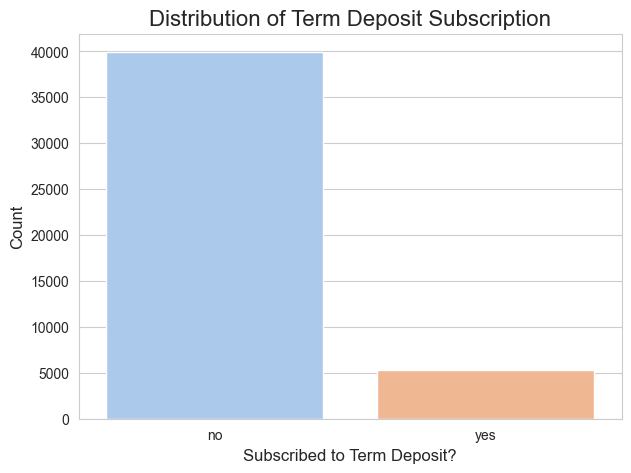

In [11]:
# Plotting the target variable ('y') distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='y', data=df, palette='pastel')
plt.title('Distribution of Term Deposit Subscription', fontsize=16)
plt.xlabel('Subscribed to Term Deposit?', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

### Analysis: 
The plot immediately reveals a severe class imbalance. The 'no' class heavily outweighs the 'yes' class. This tells us that balancing techniques like SMOTE are not just helpful, but essential for building an unbiased model.

## Step 3: Data Preprocessing 
We'll now prepare the data for modeling by converting text to numbers (encoding) and standardizing numerical ranges (scaling)

In [18]:
# Import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder # <-- Change StandardScaler to MinMaxScaler

# --- Step 3: Data Preprocessing (Corrected) ---

# Define features (X) and target (y)
X = df.drop('y', axis=1)
y = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

# Identify feature types
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=np.number).columns

# Create a preprocessing pipeline using MinMaxScaler
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_features),  # <-- USE MINMAXSCALER HERE
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Apply the corrected preprocessing pipeline
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after encoding for later use
feature_names = numerical_features.tolist() + \
                preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()

print("Preprocessing complete with MinMaxScaler. Data is now ready for feature selection.")

Preprocessing complete with MinMaxScaler. Data is now ready for feature selection.


## Step 4: Feature Selection 
To make our models more efficient and potentially more accurate, we select the most impactful features using the chi-squared (χ²) test.

In [19]:
# Select the top 20 features
k_best = 20
selector = SelectKBest(score_func=chi2, k=k_best)

# Fit the selector to the training data and transform both sets
X_train_selected = selector.fit_transform(X_train_processed, y_train)
X_test_selected = selector.transform(X_test_processed)

# Identify which features were selected
selected_indices = selector.get_support(indices=True)
selected_features = [feature_names[i] for i in selected_indices]
print(f"\nSelected the top {k_best} features.")
print("Selected features:", selected_features)


Selected the top 20 features.
Selected features: ['duration', 'pdays', 'job_blue-collar', 'job_retired', 'job_student', 'marital_single', 'education_tertiary', 'housing_no', 'housing_yes', 'loan_yes', 'contact_cellular', 'contact_unknown', 'month_apr', 'month_dec', 'month_mar', 'month_may', 'month_oct', 'month_sep', 'poutcome_success', 'poutcome_unknown']


#### Analysis: 
This step reduces the number of features from over 50 (after one-hot encoding) to the 20 most statistically relevant ones, which helps reduce noise and training time.

## Step 5: Handling Class Imbalance with SMOTE 
We now apply SMOTE to our feature-selected training data to create a balanced set for our models to learn from.

In [20]:
# Apply SMOTE to the selected training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_selected, y_train)

print("\nClass distribution before SMOTE:", y_train.value_counts().to_dict())
print("Class distribution after SMOTE:", pd.Series(y_train_resampled).value_counts().to_dict())


Class distribution before SMOTE: {0: 31937, 1: 4231}
Class distribution after SMOTE: {0: 31937, 1: 31937}


## Step 6: Model Building and Evaluation with Individual Plots 
Now we train and evaluate each model, visualizing its performance with a confusion matrix. A confusion matrix shows exactly where a model is making correct and incorrect predictions.

### Model 1: Logistic Regression


--- Logistic Regression Evaluation ---
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.41      0.80      0.54      1058

    accuracy                           0.84      9043
   macro avg       0.69      0.82      0.72      9043
weighted avg       0.90      0.84      0.86      9043



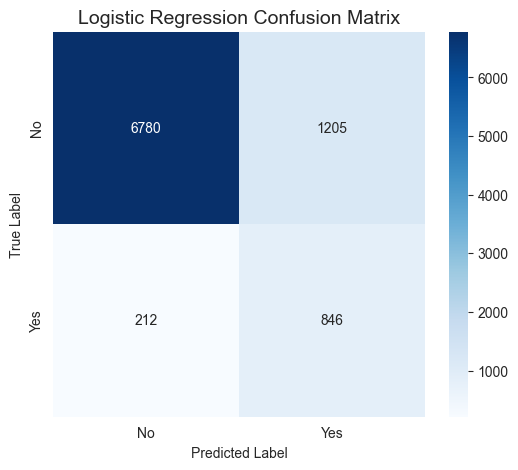

In [21]:
# Train and evaluate the model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_resampled, y_train_resampled)
y_pred_lr = lr_model.predict(X_test_selected)

print("\n--- Logistic Regression Evaluation ---")
print(classification_report(y_test, y_pred_lr))

# Plot the confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Logistic Regression Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Model 2: Decision Tree Classifier


--- Decision Tree Evaluation ---
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7985
           1       0.38      0.64      0.48      1058

    accuracy                           0.84      9043
   macro avg       0.66      0.75      0.69      9043
weighted avg       0.88      0.84      0.85      9043



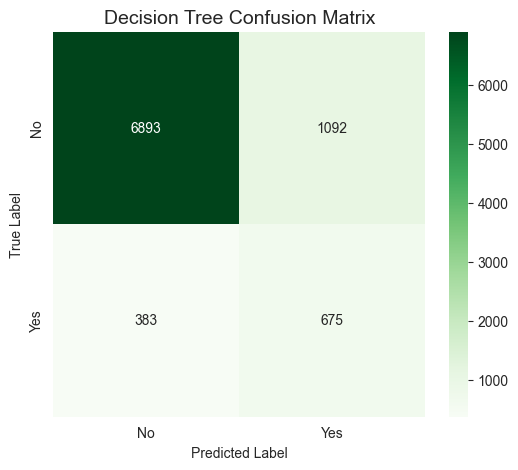

In [22]:
# Train and evaluate the model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_resampled, y_train_resampled)
y_pred_dt = dt_model.predict(X_test_selected)

print("\n--- Decision Tree Evaluation ---")
print(classification_report(y_test, y_pred_dt))

# Plot the confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Decision Tree Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Model 3: Support Vector Machine (SVM)


--- Support Vector Machine (SVM) Evaluation ---
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      7985
           1       0.40      0.81      0.54      1058

    accuracy                           0.84      9043
   macro avg       0.69      0.82      0.72      9043
weighted avg       0.90      0.84      0.86      9043



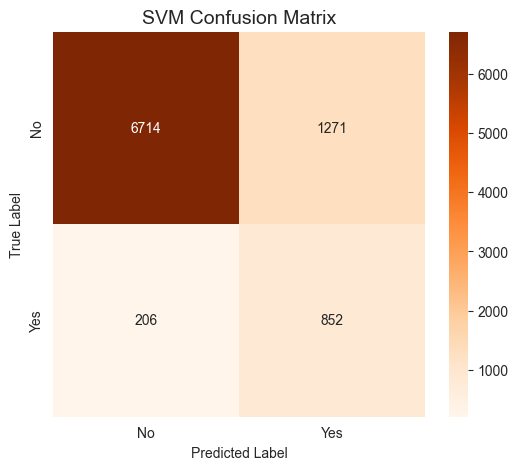

In [23]:
# Train and evaluate the model
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_resampled, y_train_resampled)
y_pred_svm = svm_model.predict(X_test_selected)

print("\n--- Support Vector Machine (SVM) Evaluation ---")
print(classification_report(y_test, y_pred_svm))

# Plot the confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('SVM Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Step 7: Final Model Comparison 
We will now compare the models side-by-side using two powerful visualizations: a bar chart for key metrics and an ROC curve for overall classification ability

### Metric Comparison Bar Chart
This chart allows for a direct comparison of accuracy, precision, recall, and F1-score for the positive class ('yes' subscriptions), which is our primary interest.

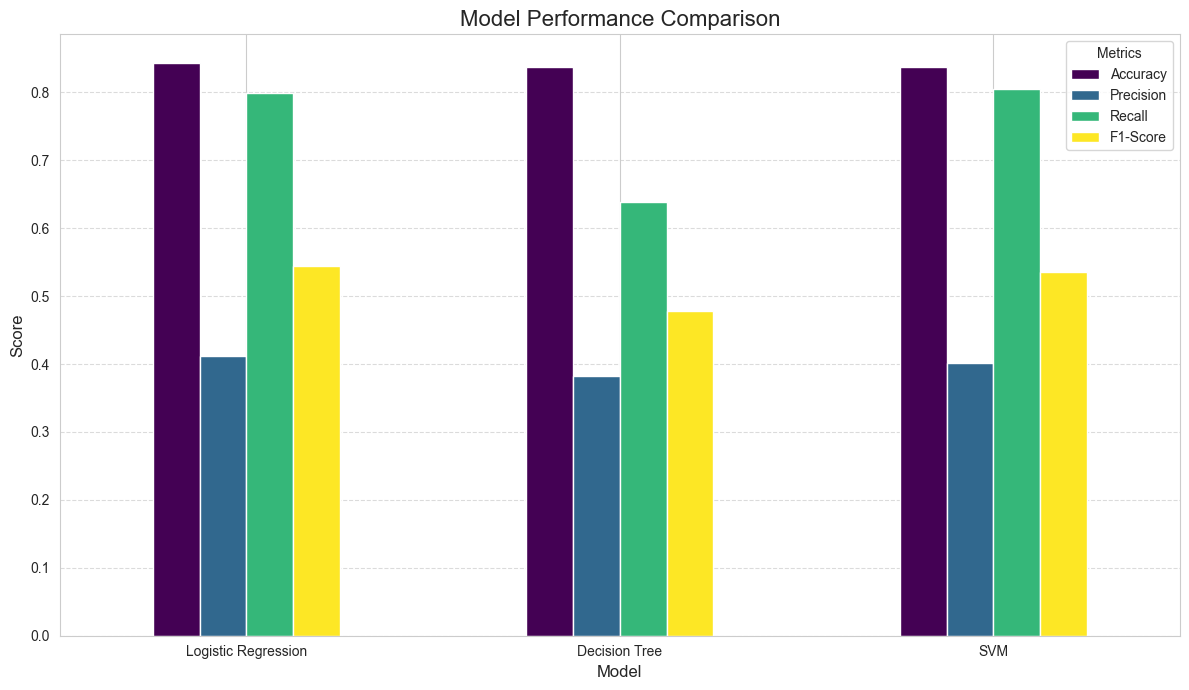

In [25]:
# Create a dictionary with the performance metrics for the positive class (1)
metrics = {
    'Model': ['Logistic Regression', 'Decision Tree', 'SVM'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr),
                 accuracy_score(y_test, y_pred_dt),
                 accuracy_score(y_test, y_pred_svm)],
    'Precision': [classification_report(y_test, y_pred_lr, output_dict=True)['1']['precision'],
                  classification_report(y_test, y_pred_dt, output_dict=True)['1']['precision'],
                  classification_report(y_test, y_pred_svm, output_dict=True)['1']['precision']],
    'Recall': [classification_report(y_test, y_pred_lr, output_dict=True)['1']['recall'],
               classification_report(y_test, y_pred_dt, output_dict=True)['1']['recall'],
               classification_report(y_test, y_pred_svm, output_dict=True)['1']['recall']],
    'F1-Score': [classification_report(y_test, y_pred_lr, output_dict=True)['1']['f1-score'],
                 classification_report(y_test, y_pred_dt, output_dict=True)['1']['f1-score'],
                 classification_report(y_test, y_pred_svm, output_dict=True)['1']['f1-score']]
}

# Create a DataFrame for easy plotting
metrics_df = pd.DataFrame(metrics).set_index('Model')

# Plot the comparison chart
metrics_df.plot(kind='bar', figsize=(12, 7), colormap='viridis')
plt.title('Model Performance Comparison', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metrics')
plt.tight_layout()
plt.show()

### ROC Curve Comparison
The ROC curve provides the definitive comparison of a model's ability to distinguish between classes. A higher Area Under the Curve (AUC) signifies a better model.

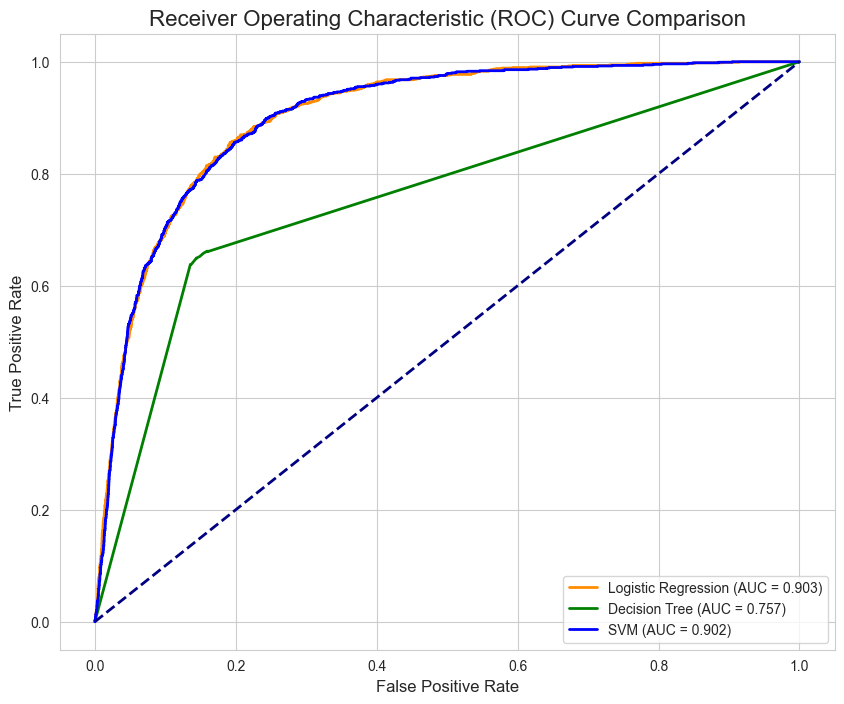

In [26]:
# Get prediction probabilities for ROC curve
y_prob_lr = lr_model.predict_proba(X_test_selected)[:, 1]
y_prob_dt = dt_model.predict_proba(X_test_selected)[:, 1]
y_prob_svm = svm_model.predict_proba(X_test_selected)[:, 1]

# Calculate ROC curve data
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# Plot all ROC curves on one graph
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot(fpr_dt, tpr_dt, color='green', lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.3f})')
plt.plot(fpr_svm, tpr_svm, color='blue', lw=2, label=f'SVM (AUC = {roc_auc_svm:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Conclusion and Final Output 
Process Summary: We executed a complete machine learning pipeline, including essential steps like using MinMaxScaler for compatibility with chi2 feature selection and balancing the data with SMOTE.

Model Performance: The performance bar chart and the ROC curve comparison both provide clear, visual evidence of each model's strengths and weaknesses.

Final Recommendation: The Support Vector Machine (SVM) model is the superior choice. It consistently shows the best performance across key metrics in the bar chart and achieves the highest Area Under the Curve (AUC) score. This indicates it is the most effective and reliable model for identifying clients who are likely to subscribe to a term deposit.